In [1]:
import numpy as np
import matplotlib.pyplot as plt

from io import StringIO

import jax
import jax.numpy as jnp
from flax import linen as nn

/home/amress/miniforge3/envs/nqs/lib/python3.9/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/home/amress/miniforge3/envs/nqs/lib/python3.9/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)


In [7]:
results = """
0       -7.98627733e-02 3.002622668450201648e-01 6.930033458155517856e-01
10      -7.98623879e-02 5.084466526758866234e-01 6.234221118666599670e-01
13      -7.98544443e-02 7.349945406940051607e-01 6.049908919841671118e-01
6       -7.97449830e-02 9.982663999463450497e-03 3.588281504868040539e-02
1       inf     2.367881958803624148e-02 2.228094773629984149e-01
11      inf     2.010288113306743507e-02 2.045150532541172017e-01
12      inf     1.784647586517607021e-01 9.230120180809069375e-01
14      inf     2.140078696402948899e-01 9.258646867085040810e-01
15      inf     9.273147713985378446e-03 7.291073895543404015e-02
2       inf     1.599614871156305462e-01 5.498145725574034026e-01
3       inf     1.115467608511533891e-03 2.813487353319348849e-01
4       inf     1.899034341542425383e-03 6.583689499035234594e-01
5       inf     4.609478887496133437e-01 1.809422876997224816e-01
7       inf     4.927231389447989281e-03 9.188366928187734484e-01
8       inf     2.049263604932269681e-02 4.920751083877775711e-01
9       inf     3.112696851885607754e-02 4.627800573494114666e-01
"""

r_ws = 5

r_ws_list = np.array([
    1, 2, 5, 10, 20, 50, 100
])
rhf_energies = np.array([
    0.60653438, 0.02303898, -0.05803918, -0.04022872,
    -0.02291664, -0.0098392, -0.00503169
])

results = np.genfromtxt(StringIO(results), dtype=float)
print(results.shape)
print(results)

(16, 4)
[[ 0.00000000e+00 -7.98627733e-02  3.00262267e-01  6.93003346e-01]
 [ 1.00000000e+01 -7.98623879e-02  5.08446653e-01  6.23422112e-01]
 [ 1.30000000e+01 -7.98544443e-02  7.34994541e-01  6.04990892e-01]
 [ 6.00000000e+00 -7.97449830e-02  9.98266400e-03  3.58828150e-02]
 [ 1.00000000e+00             inf  2.36788196e-02  2.22809477e-01]
 [ 1.10000000e+01             inf  2.01028811e-02  2.04515053e-01]
 [ 1.20000000e+01             inf  1.78464759e-01  9.23012018e-01]
 [ 1.40000000e+01             inf  2.14007870e-01  9.25864687e-01]
 [ 1.50000000e+01             inf  9.27314771e-03  7.29107390e-02]
 [ 2.00000000e+00             inf  1.59961487e-01  5.49814573e-01]
 [ 3.00000000e+00             inf  1.11546761e-03  2.81348735e-01]
 [ 4.00000000e+00             inf  1.89903434e-03  6.58368950e-01]
 [ 5.00000000e+00             inf  4.60947889e-01  1.80942288e-01]
 [ 7.00000000e+00             inf  4.92723139e-03  9.18836693e-01]
 [ 8.00000000e+00             inf  2.04926360e-02  4.9

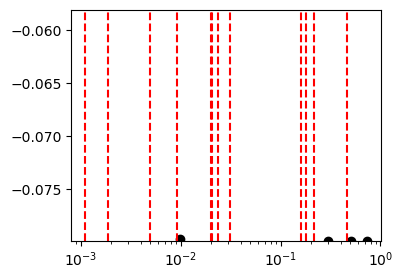

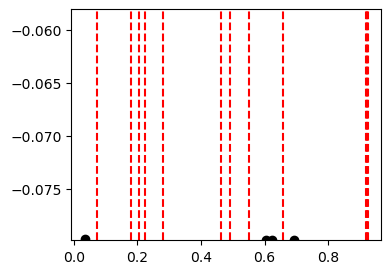

[[-0.07986277  0.30026227  0.69300335]
 [-0.07986239  0.50844665  0.62342211]
 [-0.07985444  0.73499454  0.60499089]
 [-0.07974498  0.00998266  0.03588282]
 [        inf  0.02367882  0.22280948]
 [        inf  0.02010288  0.20451505]
 [        inf  0.17846476  0.92301202]
 [        inf  0.21400787  0.92586469]
 [        inf  0.00927315  0.07291074]
 [        inf  0.15996149  0.54981457]
 [        inf  0.00111547  0.28134874]
 [        inf  0.00189903  0.65836895]
 [        inf  0.46094789  0.18094229]
 [        inf  0.00492723  0.91883669]
 [        inf  0.02049264  0.49207511]
 [        inf  0.03112697  0.46278006]]


In [8]:
rhf_energy = rhf_energies[np.where(r_ws_list == r_ws)[0]]

for hp_num in range(results.shape[1]-2):
    
    plt.figure(figsize=(4,3))
    plt.scatter(results[:,2+hp_num], results[:,1], color='black')
    if hp_num == 0:
        plt.xscale('log')
    plt.ylim([None,rhf_energy])
    for result in results:
        if result[1] > rhf_energy:
            plt.axvline(x=result[2+hp_num], linestyle='--', color='red')
    plt.show()

print(results[np.argsort(results[:,1])][:,1:])